In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. О джунглях и сокровищах (3 балла)

## 1.1 Создание матриц (0.25 балла)

Создайте 4 матрицы
- A - "шахматную" из нулей и единиц, размера 6 на 3, левое верхнее значение (A[0][0]) равно 1,
- В - из чисел от 1 до 24, записанных в виде змейки, размера 6 на 4,
- C - из случайных целых чисел от 2 до 10 (обе границы включительно), размера 4 на 3
- D - из нулей с единичками на главной диагонали, размера 4 на 4.

**Создайте из этих матриц "лоскутную" матрицу S**

A В

С D

используя **только стандартные** операции numpy. Comprehensions использовать нельзя.

После этого допишите к полученной матрице S матрицу F размера 10 на 2 из нулей, чтобы получилась матрица G:

S F

P.S. Когда мы говорим, что матрица имеет размер x на y, x - количество строк, y - количество столбцов.

In [ ]:
A = np.arange(18).reshape(6, 3) % 2
B = np.arange(1, 25).reshape(6, 4)
B[1::2] = B[1::2, ::-1]
C = np.random.randint(2, 11, size = (4, 3))
D = np.eye(4)

S = np.concatenate([np.hstack([A, B]), np.hstack([C, D])])

F = np.zeros((10, 2))

G = np.hstack([S, F])

## 1.2 Поиск ближайшего соседа (0.25 балла)

Реализуйте функцию, принимающую на вход матрицу X и некоторое число a и возвращающую ближайший к числу элемент матрицы.
Например, для X = np.arange(0,10).reshape((2, 5)) и a = 3.6 ответом будет 4. Можно пользоваться только базовыми функциями numpy, циклами пользоваться **нельзя**.

In [ ]:
def find_nearest_neighbour(X, a):
    return X.flatten()[np.abs(X - a).argmin()]

## 1.3 Очень странная нейросеть (0.25 балла)

Реализуйте одну очень странную нейросеть. Нейросеть должна:

- Возводить матрицу A (матрицу весов) размера N x N в квадрат
- В качестве первого преобразования умножать вектор X длины N (вектор признаков) на матрицу весов A**2 (на выходе получается новый вектор);
- В качестве второго преобразования умножать вектор, полученный на прошлом шаге, на вектор b (вектор весов) размера N (на выходе получается скалярное число).

Считаем, что все числа (элементы матриц и векторов) - числа с плавающей точкой.

In [ ]:
A = np.arange(0, 25, dtype=float).reshape(5, 5)
b = np.arange(25, 30, dtype=float)
X = np.arange(30, 35, dtype=float)

def very_strange_neural_network(A, b, X):
    return b @ (X @ (A @ A))


print(very_strange_neural_network(A, b, X))

17135500.0


## 1.4 Джунгли зовут! (0.25 балла)

Перед вами матрица M - карта местности тяжелопроходимых джунглей, составленная Ларой Крофт. На карте каждая ячейка - целое число, обозначающее высоту над уровнем моря (если число больше нуля) в метрах или глубину моря (если число меньше нуля) в метрах в данной ячейке карты размером метр на метр. Если число 0, то это часть суши - берег.


Вам необходимо посчитать:
- Общую площадь клеточек моря, в которых его глубина больше 5 (в м^2)
- Общий объём всей воды на карте (в м^3)
- Максимальную высоту над уровнем моря, которая есть на этой карте (в м)

In [ ]:
def find_deep_sea_area(M):
    return len(M[M < -5])

def find_water_volume(M):
    return abs(sum(M[M < 0]))

def find_max_height(M):
    return M.max()

In [ ]:
# Можно подставить свой пример
M = np.array([
    [-7, -3, -1, 0],
    [-4, -3, 1, 19],
    [-2, 0, 4, 25],
    [-1, 3, 6, 9]
])

# простая проверка для примера выше
assert np.isclose(find_deep_sea_area(M), 1)
assert np.isclose(find_water_volume(M), 21)
assert np.isclose(find_max_height(M), 25)

print("Общая площадь моря (по условию тут глубиной больше 5 м) на карте -", find_deep_sea_area(M), "м^2")
print("Общий объем воды на карте -", find_water_volume(M), "м^3")
print("Максимальный уровень над уровнем моря на карте -", find_max_height(M), "м")

Общая площадь моря (по условию тут глубиной больше 5 м) на карте - 1 м^2
Общий объем воды на карте - 21 м^3
Максимальный уровень над уровнем моря на карте - 25 м


## 1.5 Острова сокровищ (0.25 балла)


На вход функции подаётся массив a из нулей и единиц. Необходимо посчитать, сколько в массиве есть блоков из идущих подряд единиц (островков). Можно пользоваться только базовыми функциями numpy, циклами пользоваться **нельзя**.

Подсказка: посмотрите, что такое `np.diff`

In [ ]:
def count_all_islands(a):
  a = np.diff(np.concatenate([a, [0]]))
  return len(a[a < 0])

In [ ]:
# можно подставить свой пример

a = np.array([0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1])

# простая проверка для примера выше
assert count_all_islands(a) == 4
print(count_all_islands(a))

4


## 1.6 Маскарад (0.25 балла)

На вход идёт 2-мерная матрица X, заполненная целыми числами, и число a (м.б. дробное). Нужно заменить все ячейки в матрице, которые больше, чем а, на среднее значение среди элементов матрицы Х (мы не округляем, а отбрасываем числа после запятой).

**Нужно** пользоваться базовыми функциями numpy, **нельзя** пользоваться циклами.

In [ ]:
def swap_mask_for_average(X, a):
  X[X > a] = X.mean()
  return X

In [ ]:
# Можно подставить свой пример
M = np.array([
    [-7, -3, -1, 0],
    [-4, -3, 1, 19],
    [-2, 0, 4, 25],
    [-1, 3, 6, 9]
])
a = 5

# простая проверка для примера выше
assert np.allclose(swap_mask_for_average(M, a),
                   np.array([
                       [-7, -3, -1, 0],
                       [-4, -3, 1, 2],
                       [-2, 0, 4, 2],
                       [-1, 3, 2, 2]
                   ]))

swap_mask_for_average(M, a)

array([[-7, -3, -1,  0],
       [-4, -3,  1,  2],
       [-2,  0,  4,  2],
       [-1,  3,  2,  2]])

## 1.7 Функция проверки (0.75 балла)

На вход функции поступает произвольное (>2) кортежей размеров (shape) различных матриц. Необходимо вернуть True если можно последовательно сложить эти матрицы (возможно, с помощью broadcasting), и False если нет.

In [ ]:
def check_successful_broadcast(*matrices):
    if len(matrices) == 0:
        return True
    m_len = max(len(shape) for shape in matrices)
    shapes = []
    for shape in matrices:
        shapes.append((1,) * (m_len - len(shape)) + shape)
    for i in range(m_len):
        sizes = [shape[i] for shape in shapes]
        not_one = {size for size in sizes if size != 1}
        if len(not_one) > 1:
            return False
    return True

In [ ]:
assert check_successful_broadcast((5, 6, 7), (6, 7), (1, 7))
# можно ещё потестировать на своих примерах

## 1.8 Попарные расстояния (0.75 балла)

На вход подаются матрицы A размера m x k и матрица B размера n x k. Нужно получить матрицу размера m x n, содержащую попарные евклидовы расстояния.

Можно пользоваться только базовыми функциями, нельзя пользоваться циклами, сторонними библиотеками; скорее всего, пригодится broadcasting. Авторское решение записывается **в одну строчку** в соответствии со всеми правилами кодстайла.

In [ ]:
def pairwise_distances(A, B):
    return np.sqrt(np.sum((A[:, np.newaxis, :]-B[np.newaxis, :, :])**2, axis=2))

In [ ]:
A = np.arange(15).reshape(5, 3)
B = np.arange(18).reshape(6, 3)

pairwise_distances(A, B)

array([[ 0.        ,  5.19615242, 10.39230485, 15.58845727, 20.78460969,
        25.98076211],
       [ 5.19615242,  0.        ,  5.19615242, 10.39230485, 15.58845727,
        20.78460969],
       [10.39230485,  5.19615242,  0.        ,  5.19615242, 10.39230485,
        15.58845727],
       [15.58845727, 10.39230485,  5.19615242,  0.        ,  5.19615242,
        10.39230485],
       [20.78460969, 15.58845727, 10.39230485,  5.19615242,  0.        ,
         5.19615242]])

Объясни принцип работы этой одной строчки. Что именно происходит в ней?

<font color='white'>Сперва мы делаем "уголок" из матриц общая сторона матриц в нем это сторона размерности k, затем происходит заполнение 3-мерной матрицы разностями и возведение их в квадрат, после разности суммируются по вертикальной оси (оси размера k). Получили матрицу размера m на n, остается только извлечь из каждого элемента квадратный корень и получаем ответ на задачу.</font>

# 2. О накручивании себя и чёрном саморезе (2 балла)

А сейчас, дамы и господа, мы научимся использовать библиотеки для анализа данных в реальности!

**Причина появления этого раздела проста**: многие студенты ПМФ даже во втором и третьем семестрах продолжают использовать Excel, калькулятор или лист бумаги. Хочется открыть глаза на ещё один способ выполнения лабораторных с намного меньшим порогом вхождения, чем тот же Excel. Авторы надеются, что кого-то это замотивирует присмотреться к удобным библиотекам.

*Спонсор данных для раздела - blacksamorez. Без него пять счастливых семестров лаб были бы совсем не счастливыми...*

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##  2.1. Постановка задачи и данные

Предположим, у нас есть гироскоп с прицепленным к его оси грузом на рычаге (см. рисунок для быстрого понимания, а подробности можно узнать в [лабораторном практикуме](https://lib.mipt.ru/book/267519/), том 1, стр.160). Из-за наличия груза гироскоп начинает медленно [прецессировать](https://ru.wikipedia.org/wiki/%D0%9F%D1%80%D0%B5%D1%86%D0%B5%D1%81%D1%81%D0%B8%D1%8F), т.е. вращаться вокруг вертикальной оси с какой-то более-менее постоянной частотой.

Мы с вами разберём часть этой лабораторной, в основном касающуюся обработки данных и построения графиков.

<center><img src='https://drive.google.com/uc?export=view&id=1KfYQ0hKYRDhi5uk7C8lNffZBNy8NF7nu' width=600>

Изображение гироскопа с подвешенным грузом Г и рычагом С</center>

Для начала посмотрим на данные, которые любезно кто-то для нас собрал. Создайте датафрейм из [файла](https://drive.google.com/file/d/1SbLR6R16obqLewUTnX1CAAjQTrVXh2Vq/view?usp=sharing)

In [ ]:
data = pd.read_csv('/content/sample_data/data_numpy_lab.csv')
data.head()

,Unnamed: 0,N,"t, sec","sigma_t, sec","mass, gramm","length, cm","phi, rad"
0,1,4,268,1,180.0,121.0,0.16
1,2,4,264,1,180.0,121.0,0.18
2,3,4,275,1,180.0,121.0,0.16
3,4,4,263,1,180.0,121.0,0.17
4,5,4,267,1,180.0,121.0,0.17


## 2.2 Работа с данными (1 балл)

Колонки в датафрейме следующие:

N - количество полных оборотов гироскопа в эксперименте;

t, в секундах - время эксперимента;

$\sigma_t$ - погрешность измерения времени;

mass - масса груза, подвешенного к рычагу на гироскопе;

length - длина плеча вышеупомянутого рычага;

phi - угол в радианах, на который опустился рычаг за время эксперимента. Понадобится, чтобы оценить влияние силы трения в гироскопе на прецессию.

Так как физики любят оперировать величинами адекватной размерности, нужно перевести колонки с массой в килограммы, а с длиной - в метры. Затем переименуйте все колонки так, чтобы в них не осталось упоминаний о размерности - только названия физических величин.

In [ ]:
data = data.drop(columns='Unnamed: 0') # у меня какая-то странная колонка была
data = data.rename(columns={
    't, sec': 't',
    'sigma_t, sec': 'sigma_t',
    'mass, gramm': 'mass',
    'length, cm': 'length',
    'phi, rad': 'phi'
})
data['mass'] = data['mass']/1000
data['length'] = data['length']/100

assert data.mass.mean() < 0.3
assert np.allclose(data.length.mean(), 1.155)
assert all(' ' not in column for column in data.columns)

data.head()

,N,t,sigma_t,mass,length,phi
0,4,268,1,0.18,1.21,0.16
1,4,264,1,0.18,1.21,0.18
2,4,275,1,0.18,1.21,0.16
3,4,263,1,0.18,1.21,0.17
4,4,267,1,0.18,1.21,0.17


Добавьте в датафрейм колонки с соответствующими именами и значениями, вычисленными по формулам:

`omega`: $\Omega = 2 \pi \cdot \frac{N}{t}$

`sigma_omega`: $\sigma_{\Omega} = \Omega / t \cdot \sigma_t$

`omega_down`: $\Omega_{down} = \varphi / t$

`sigma_down`: $\sigma_{down} =\Omega_{down} \cdot \sigma_t / t$

`momentum`: $M = m \cdot g \cdot l$ (`g = 9.8 м/с^2`)

`momentum_down`: $M_{down} = m \cdot \frac{\varphi}{t^2} \cdot l^2$

`sigma_momentum`: $\sigma_{M} = M_{down} \cdot 2 \cdot \frac{\sigma_t}{t}$


In [ ]:
g = 9.8
data['omega'] = 2*np.pi*data['N'] / data['t']
data['sigma_omega'] = data['omega'] / data['t'] * data['sigma_t']
data['omega_down'] = data['phi'] / data['t']
data['sigma_down'] = data['omega_down'] * data['sigma_t'] / data['t']
data['momentum'] = data['mass'] * g * data['length']
data['momentum_down'] = data['mass'] * (data['phi'] / data['t']**2) * data['length']**2
data['sigma_momentum'] = data['momentum_down'] * 2 * data['sigma_t'] / data['t']

assert np.allclose(data.momentum_down.iloc[0], 5.892e-07)
assert np.allclose(data.sigma_omega[0:5], 3.5e-04, atol=3e-5)
assert np.allclose(data.sigma_momentum[0:5], 4.4e-09, atol=1e-9)

data.head()


,N,t,sigma_t,mass,length,phi,omega,sigma_omega,omega_down,sigma_down,momentum,momentum_down,sigma_momentum
0,4,268,1,0.18,1.21,0.16,0.093779,0.000350,0.000597,0.000002,2.13444,5.870751e-07,4.381157e-09
1,4,264,1,0.18,1.21,0.18,0.095200,0.000361,0.000682,0.000003,2.13444,6.806250e-07,5.156250e-09
2,4,275,1,0.18,1.21,0.16,0.091392,0.000332,0.000582,0.000002,2.13444,5.575680e-07,4.055040e-09
3,4,263,1,0.18,1.21,0.17,0.095562,0.000363,0.000646,0.000002,2.13444,6.477101e-07,4.925552e-09
4,4,267,1,0.18,1.21,0.17,0.094130,0.000353,0.000637,0.000002,2.13444,6.284484e-07,4.707479e-09


Возможно, вы уже задались вопросом, для чего так много раз повторяются эксперименты с одной и той же массой. Чтобы получить более стабильные результаты, конечно же! Посчитайте теперь средние значения колонок `omega`, `sigma_omega`, `omega_down`, `sigma_down`, `momentum`, `momentum_down` и `sigma_momentum` для каждой уникальной массы.

**Подсказка:** функция groupby вам поможет. Никаких циклов!

In [ ]:
grouped_data = data.groupby('mass')[['omega', 'sigma_omega', 'omega_down', 'sigma_down', 'momentum', 'momentum_down', 'sigma_momentum']].mean()

assert 0.273 in grouped_data.index
assert np.allclose(grouped_data.omega[0.273], 0.1433)

grouped_data

,omega,sigma_omega,omega_down,sigma_down,momentum,momentum_down,sigma_momentum
mass,,,,,,,
0.142,0.066661,0.000236,0.000559,0.000002,1.683836,4.108862e-07,2.906917e-09
0.180,0.094012,0.000352,0.000629,0.000002,2.134440,6.202853e-07,4.645096e-09
0.216,0.081687,0.000354,0.000710,0.000003,2.286144,7.755223e-07,6.721701e-09
0.273,0.143300,0.000817,0.000935,0.000005,3.263988,2.166527e-06,2.470970e-08
0.341,0.150752,0.000723,0.000797,0.000004,3.675980,1.577406e-06,1.514038e-08
0.614,0.185194,0.000910,0.000815,0.000004,6.679092,3.030996e-06,2.978946e-08


## 2.3 Простые графики и МНК (1 балл)

Теперь время для повторного знакомства с методом наименьших квадратов. Конечно же, мы не заставим вас писать МНК самостоятельно! <s>Мы же не звери</s>


В numpy функция [np.polyfit](https://numpy.org/devdocs/reference/generated/numpy.polyfit.html) по `x`, `y` и степени `p` вычисляет многочлен заданной степени, являющийся МНК-оценкой зависимости `y(x)`.

Функция [np.polyval](https://numpy.org/devdocs/reference/generated/numpy.polyval.html), в свою очередь, вычисляет многочлен `P(x)` по заданным коэффициентам.

Ваша задача - построить график зависимости $\Omega (M)$ угловой скорости от момента инерции. На графике должны присутствовать экспериментальные точки, а также прямая, построенная по методу наименьших квадратов. В легенду вынесите полином с записанными коэффициентами. Не забудьте подписать оси (14 шрифт), задать сетку и сделать правильный заголовок (18 шрифт)!

<center><img src='https://drive.google.com/uc?export=view&id=1xumON0195iA4HGSqvpS0FAhPGxuCdKH8' width=600>

Пример получившегося графика</center>

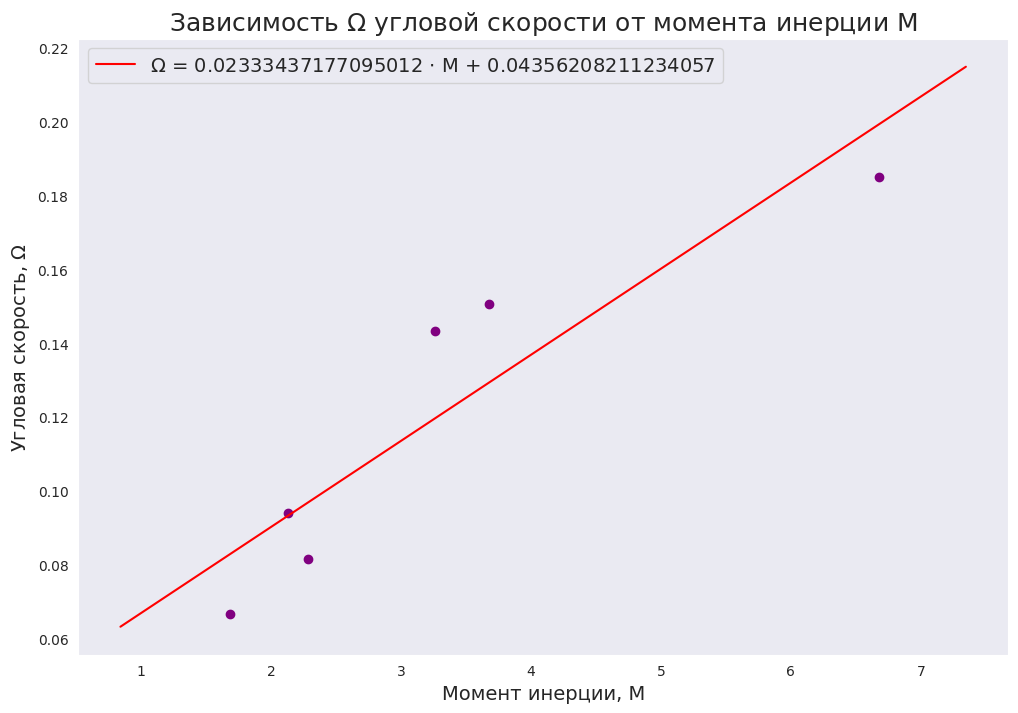

In [ ]:
omega_np = np.array(grouped_data.omega)
momentum_np = np.array(grouped_data.momentum)
coefs = np.polyfit(momentum_np, omega_np, 1)
x_lsq = np.linspace(momentum_np.min() * 0.5, momentum_np.max() * 1.1, 100)
y_lsq = np.polyval(coefs, x_lsq)

fig = plt.figure(figsize=(12, 8))
plt.title('Зависимость $\\Omega$ угловой скорости от момента инерции M', fontsize=18)
plt.xlabel('Момент инерции, M', fontsize=14)
plt.ylabel('Угловая скорость, $\\Omega$', fontsize=14)
plt.scatter(momentum_np, omega_np, c='purple')
plt.plot(x_lsq, y_lsq, 'red', label=f'$\\Omega$ = {coefs[0]} $\\cdot$ M + {coefs[1]}')
plt.legend(fontsize=14)
plt.grid()
plt.show()

`np.polyfit` также умеет оценивать погрешности! Если точнее, он возвращает матрицу ковариаций для метода наименьших квадратов. Не будем углубляться в математику, главное знать, что на диагонали у неё стоят дисперсии полученных коэффициентов. Для получения собственно погрешности $\sigma$ необходимо взять корень из этих дисперсий.

Также стоит упомянуть про параметр `W`, задающий веса точек для оценки. Если известны ошибки $y_{error}$, можно задать веса как $W = 1 / y_{error}$, и прямая получится ещё более точной. Чтобы учесть ещё и ошибки по $x$, нужны, к сожалению, уже другие методы (но скорее всего, вам не понадобятся даже ошибки по $y$).

Представим, что произошла неприятность, и погрешности возросли в 10 раз!

In [ ]:
grouped_data['sigma_down'] *= 10
grouped_data['sigma_momentum'] *= 10



Теперь вам нужно нарисовать график зависимости $\Omega_{down} (M_{down})$ <b>(не $\Omega(M)$!)</b> для точек с крестами погрешностей, а также построить не только прямую по оценке наименьших квадратов, а ещё и учесть погрешности оценок коэффициентов! Т.е. нужно построить три прямых: $k \cdot x + b$, которую выдал МНК, $(k - \sigma_k) \cdot x + (b - \sigma_b)$, $(k + \sigma_k) \cdot x + (b + \sigma_b)$, и закрасить промежуток между этими прямыми (в этом вам поможет функция plt.fill_between). Остальное оформление оставьте таким же, как в предыдущем задании.

_Примечание: часто в МНК не смотрят на погрешность $b$, оставляя только $\sigma_k$._

<center><img src='https://drive.google.com/uc?export=view&id=1SriaMzJah7F610ocIK_O1-HqqtMQgxlg' width=600>

Пример получившегося графика</center>

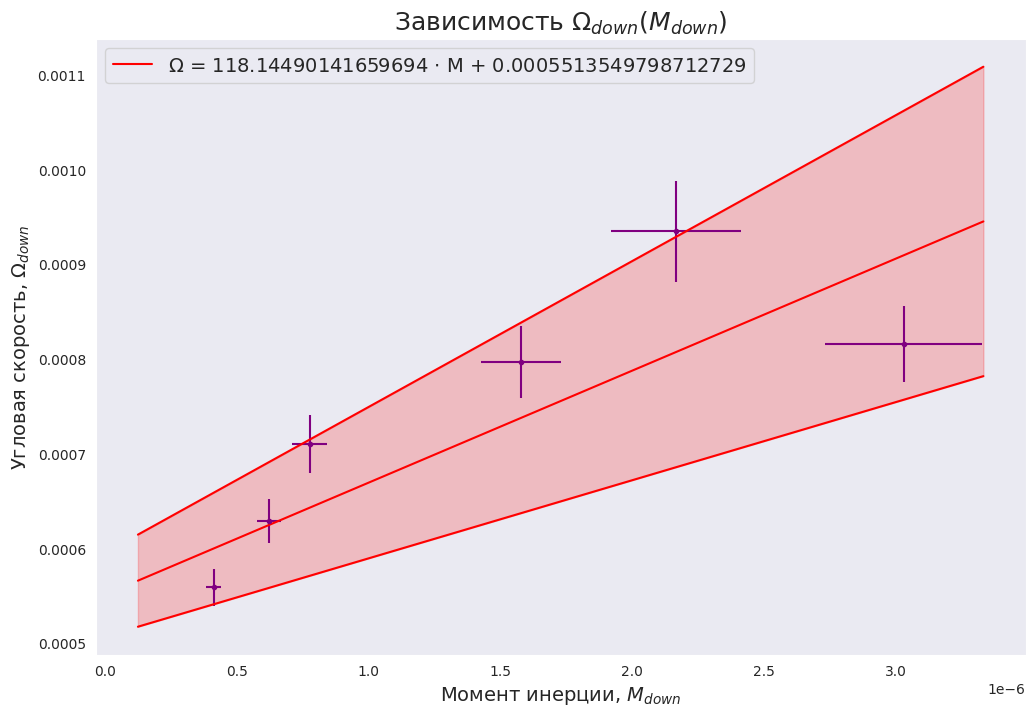

In [ ]:
omega_down_np = np.array(grouped_data.omega_down)
momentum_down_np = np.array(grouped_data.momentum_down)
sigma_omega = np.array(grouped_data.sigma_down)
sigma_momentum = np.array(grouped_data.sigma_momentum)
coefs, cov = np.polyfit(momentum_down_np, omega_down_np, 1, w=1.0 / sigma_omega, cov=True)
k = coefs[0]
b = coefs[1]
sigma_k = np.sqrt(cov[0, 0])
sigma_b = np.sqrt(cov[1, 1])
x_lsq = np.linspace(momentum_down_np.min() * 0.3, momentum_down_np.max() * 1.1, 100)

y_lsq = np.polyval([k, b], x_lsq)
y_lsq_lower = np.polyval([k - sigma_k, b - sigma_b], x_lsq)
y_lsq_upper = np.polyval([k + sigma_k, b + sigma_b], x_lsq)

fig = plt.figure(figsize=(12, 8))

plt.title('Зависимость $\\Omega_{down}(M_{down})$', fontsize=18)
plt.xlabel('Момент инерции, $M_{down}$', fontsize=14)
plt.ylabel('Угловая скорость, $\\Omega_{down}$', fontsize=14)
plt.errorbar(momentum_down_np, omega_down_np, c='purple',
             xerr=sigma_momentum, yerr=sigma_omega,
             fmt='.')
plt.plot(x_lsq, y_lsq, 'red', label=f'$\\Omega$ = {coefs[0]} $\\cdot$ M + {coefs[1]}')
plt.plot(x_lsq, y_lsq_lower, 'red')
plt.plot(x_lsq, y_lsq_upper, 'red')
plt.fill_between(x_lsq, y_lsq_lower, y_lsq_upper, alpha=0.2, color='red')
plt.legend(fontsize=14)
plt.grid()
plt.show()

# 3. О скитаниях вечных и о Palomar1 (3 балла)

Palomar 1 — шаровое скопление, входящее в группу Паломар в созвездии Цефея, расположенное, возможно, во внешнем рукаве галактики Млечный Путь. Обнаружено Джорджем О. Абеллом в 1954 году на снимках Palomar Survey Sky, его каталогизировали как **шаровое скопление**. **Шаровое звёздное скопление** — звёздное скопление, содержащее большое число звёзд, тесно связанное гравитацией и обращающееся вокруг галактического центра в качестве спутника.

Возраст скопления - от 6,3 до 8 млрд лет, что делает его очень молодым по сравнению с другими шаровыми скоплениями Млечного Пути.

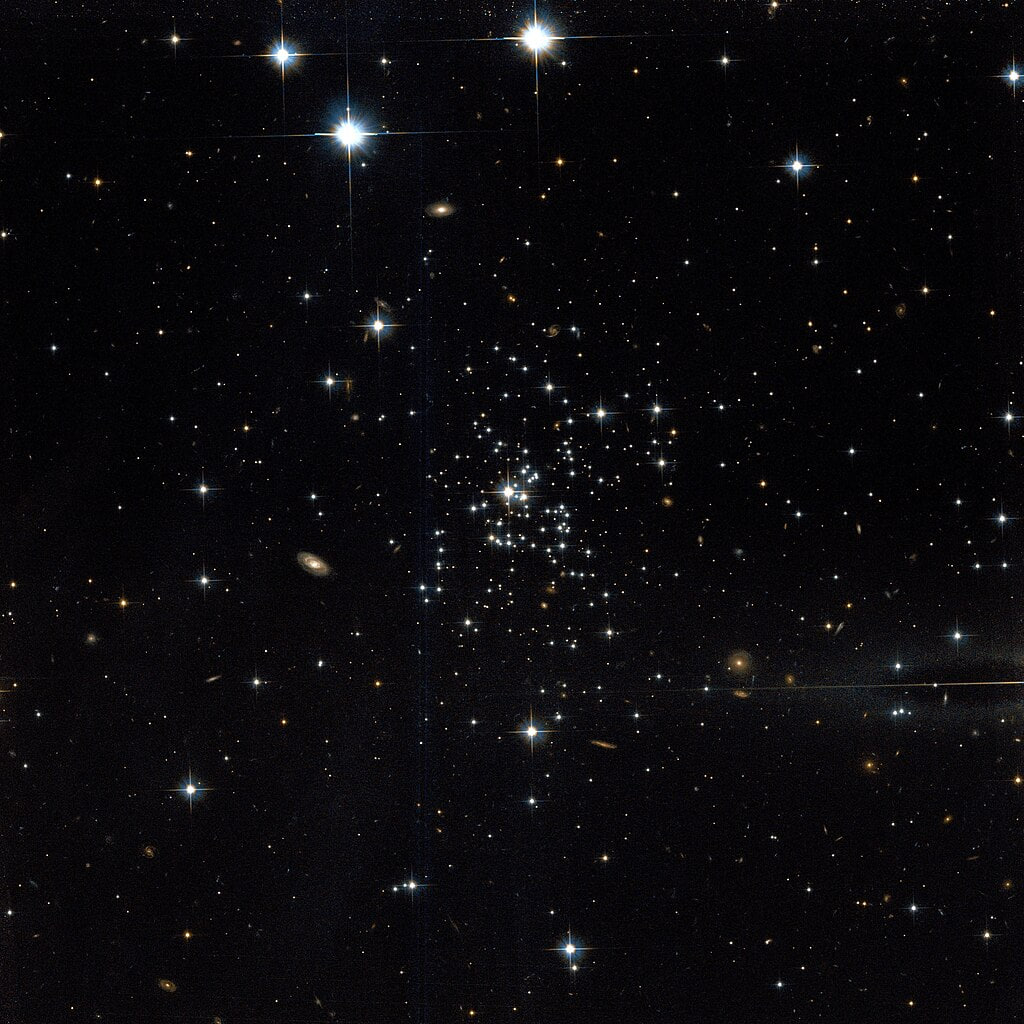

**ВАЖНО!!!**

Требования к графикам в данной главе:

- Должны быть выполнены при помощи matplotlib
- Фон цвета #519dfc с непрозрачностью 15%
- Должна быть сетка
- Должны быть название (на русском языке), подписаны оси (на русском, с размерностями, если надо), на осях должны быть отметки
- В наборе данных довольно много точек. Выбирайте столько точек, чтобы график был читаемым; зачастую если оставить все, график не будет информативным.

## 3.1 Орбита на плоскости (X; Y) (0.5 балла)

В файле Pal1_new.dat приведены расчётные положения и скорости шарового скопления Palomar1 в декартовой галактоцентрической системе координат, начиная c текущего момента. Заголовки столбцов отсутствуют. Структура файла показана в таблице (данные округлены):

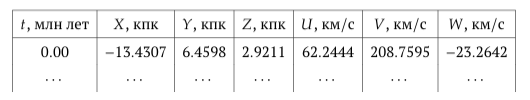

Загрузите данные из файла и постройте график координат Palomar1 на оси (X; Y).

Цвет точек должен варьироваться в зависимости от парамера t; также надо отдельно нарисовать другим цветом начальную точку и тем же цветом нарисовать вектор скорости из неё (в какую сторону движется галактика)

Градиент из легенды вынести справа от графика.

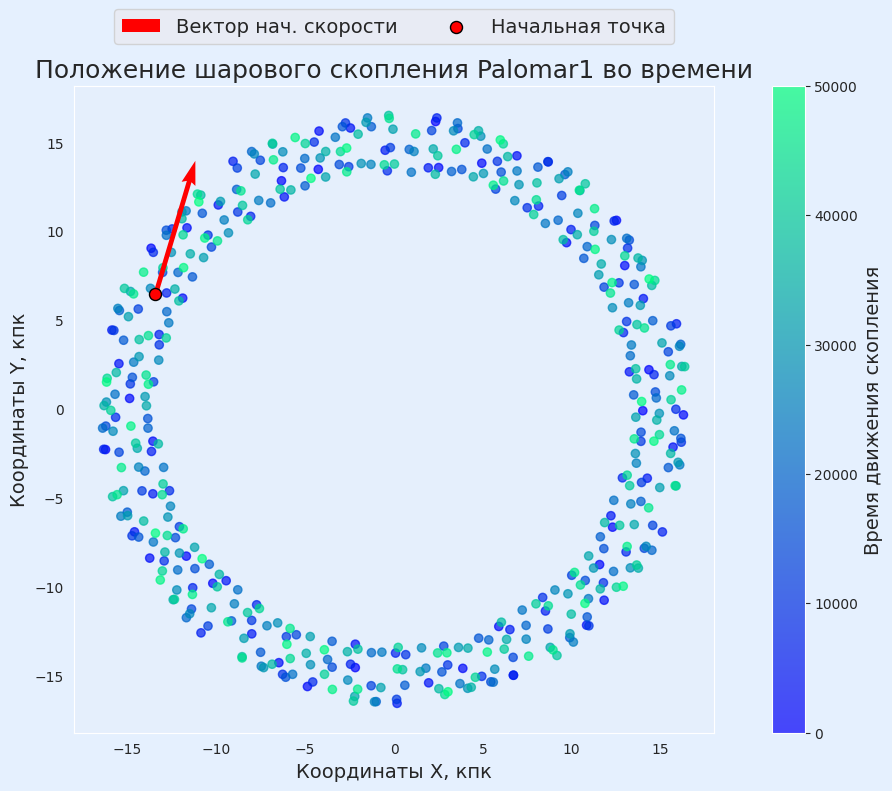

In [ ]:
columns = ['t', 'X', 'Y', 'Z', 'U', 'V', 'W']
data = pd.read_csv("/content/sample_data/Pal1_new.dat", skiprows=[0], names=columns, delimiter=' ')
group = 100
t = np.array(data['t'])[::group]
X = np.array(data["X"])[::group]
Y = np.array(data["Y"])[::group]
U = np.array(data["U"])[::group]
V = np.array(data["V"])[::group]
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#519dfc')
fig.patch.set_alpha(0.15)
ax.patch.set_alpha(0.15)
scatter = ax.scatter(X, Y, c=t, cmap='winter', alpha=0.7)
vect = ax.quiver(X[0], Y[0], U[0], V[0],
                 color='red', scale=1000,
                 label='Вектор нач. скорости')
startpos = ax.scatter(X[0], Y[0], c='red', s=300, marker='.',
                      label='Начальная точка', edgecolor='black')
bar = fig.colorbar(scatter, ax=ax)
ax.set_aspect('equal')
bar.set_label('Время движения скопления', fontsize=14)
ax.set_xlabel('Координаты X, кпк', fontsize=14)
ax.set_ylabel('Координаты Y, кпк', fontsize=14)
ax.set_title('Положение шарового скопления Palomar1 во времени', fontsize=18)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.05), ncol=3, fontsize=14)
ax.grid()
plt.tight_layout()
plt.show()

Какую информацию даёт нам этот график? Какую фигуру напоминает движение?

<font color='white'>Отследить изменение положения шарового скопления можно при помощи цветового градиента. Орбита близка к окружности, и все время своей жизни скопление двигалось примерно по окружности. Связано это вероятно с тем, что скопление сформировалось далеко от центра галактики и не испытывало серьезных гравитационных возмущений, так как сформировалось сильно позже самого Млечного пути. Из графика так же можно извлечь информацию о начальном векторе скорости шарового скопления, он слегка не перпендикулярен радиусу, поэтому наверное есть небольшой эксцентриситет.</font>

## 3.2 Аппроксимация (0.75 балла)

Придумайте, как свести наши данные к МНК из предыдущего пункта.

Подберите коэффициенты и нарисуйте график из 3.1 вместе с вашей аппроксимацией орбиты.

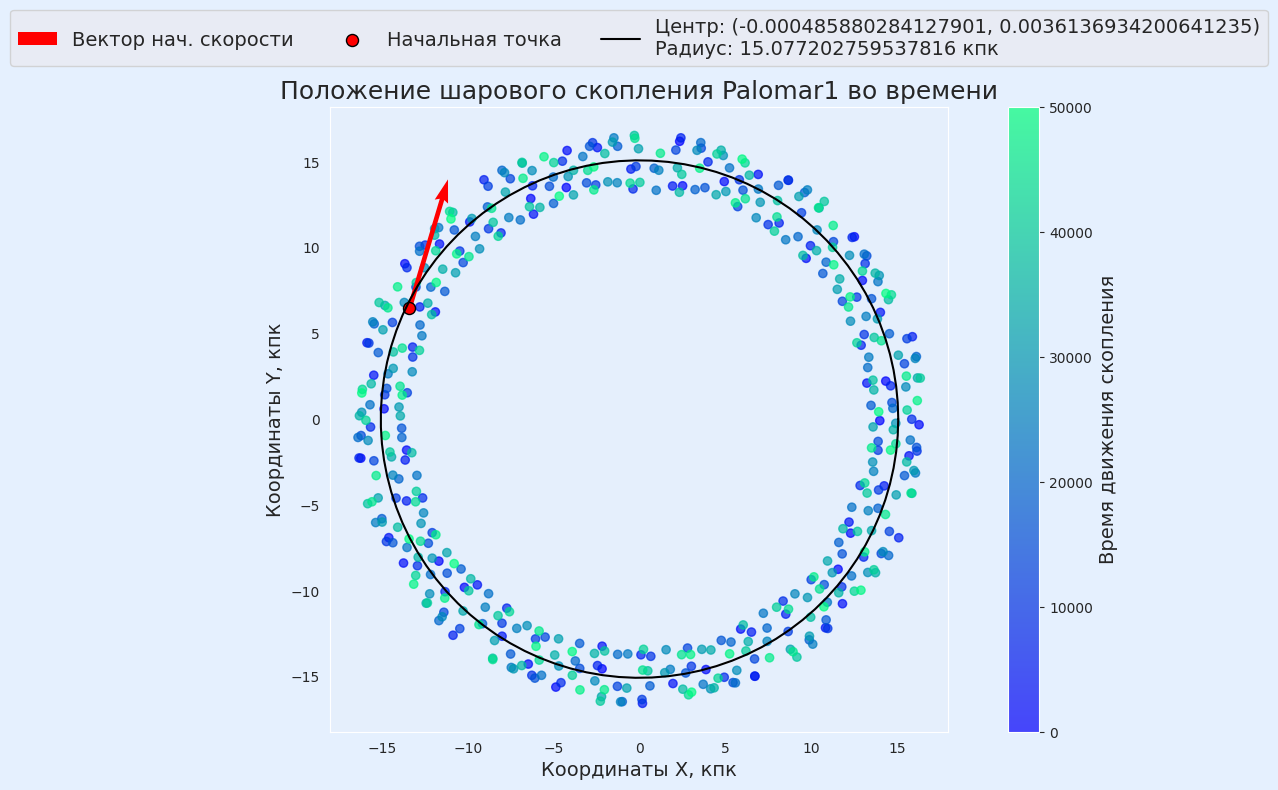

In [ ]:
def fit_circle(x, y):
    A = np.column_stack([2*x, 2*y, np.ones(len(x))])
    B = x**2 + y**2
    coeffs, _, _, _ = np.linalg.lstsq(A, B, rcond=None)
    x_0 = coeffs[0]
    y_0 = coeffs[1]
    R = np.sqrt(coeffs[2] + x_0**2 + y_0**2)
    return x_0, y_0, R

group = 100
t = np.array(data['t'])[::group]
X = np.array(data["X"])[::group]
Y = np.array(data["Y"])[::group]
U = np.array(data["U"])[::group]
V = np.array(data["V"])[::group]
x_0, y_0, R = fit_circle(X, Y)
a = np.linspace(0, 2*np.pi, 100)
X_R = x_0 + R * np.cos(a)
Y_R = y_0 + R * np.sin(a)
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#519dfc')
fig.patch.set_alpha(0.15)
ax.patch.set_alpha(0.15)
scatter = ax.scatter(X, Y, c=t, cmap='winter', alpha=0.7)
vect = ax.quiver(X[0], Y[0], U[0], V[0],
                 color='red', scale=1000,
                 label='Вектор нач. скорости')
startpos = ax.scatter(X[0], Y[0], c='red', s=300, marker='.',
                      label='Начальная точка', edgecolor='black')
ax.plot(X_R, Y_R, 'black',
        label=f'Центр: ({x_0}, {y_0})\nРадиус: {R} кпк')
bar = fig.colorbar(scatter, ax=ax)
ax.set_aspect('equal')
bar.set_label('Время движения скопления', fontsize=14)
ax.set_xlabel('Координаты X, кпк', fontsize=14)
ax.set_ylabel('Координаты Y, кпк', fontsize=14)
ax.set_title('Положение шарового скопления Palomar1 во времени', fontsize=18)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.05), ncol=3, fontsize=14)
ax.grid()
plt.tight_layout()
plt.show()

Какое понимание даёт нам такая аппроксимация? Какой эксцентриситет у этой кривой?

<font color='white'>Как мы сделали вывод в предыдущем пункте скопление не испытывает сильного гравитационного влияния, находится в относительно спокойной области галактического гало. Так же за все время сущетсования скопления не замечено никаких возмущений орбиты другими телами. Эксцентриситет такой кривой 0. Это окружность. На самом деле движение скопления выглядит как очень слабо вытянутый прецессирующий эллипс, его эксцентристет примерно 0,1. Его можно найти приняв за перигалактическое расстояние радиус малой окружности, а за афелийное радиус внешней.</font>

## 3.3 3D график (0.75 балла)

Нарисуйте 3D график координат звёздного скопления; аналогично п. 3.1 цвет должен зависеть от даты (t).

Кроме этого, нарисуйте проекцию этого графика на плоскость OXY - точки проекции все должны быть одинакового цвета вне зависимости от даты (t).

Градиент из легенды надо вынести справа от графика.

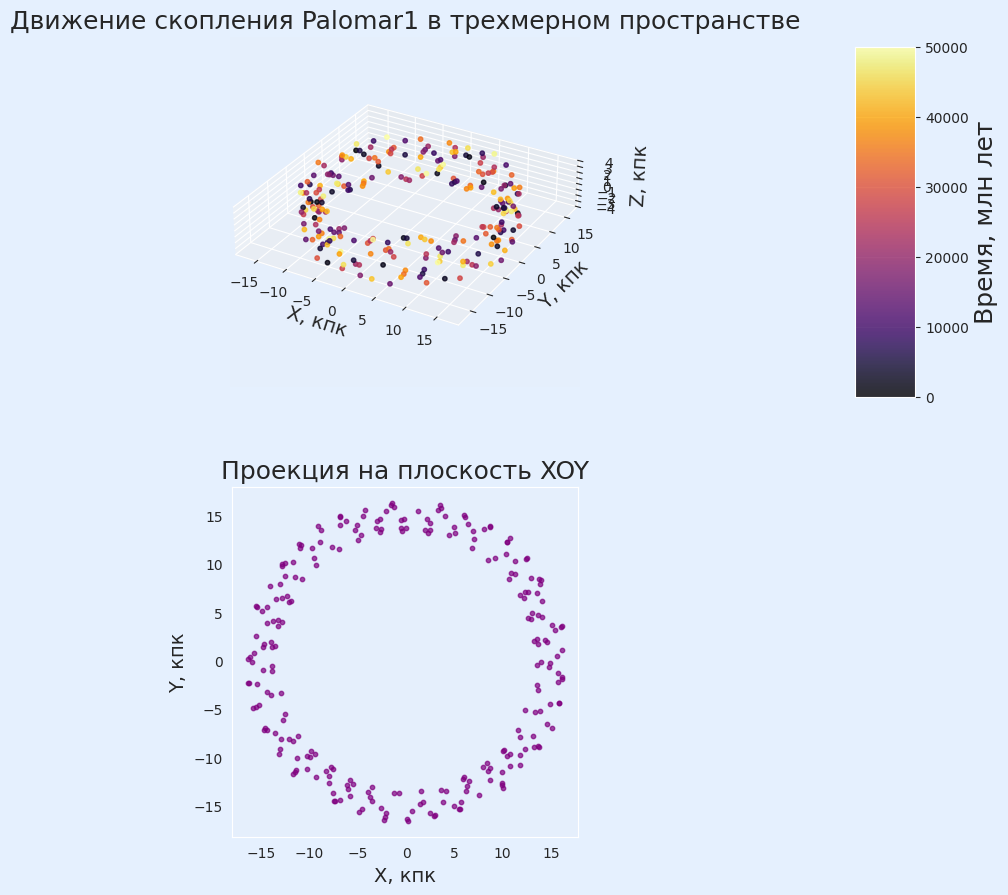

In [ ]:
group = 200
t = np.array(data['t'])[::group]
X = np.array(data["X"])[::group]
Y = np.array(data["Y"])[::group]
Z = np.array(data["Z"])[::group]
fig = plt.figure(figsize=(15, 10))
fig.patch.set_facecolor('#519dfc')
fig.patch.set_alpha(0.15)
left, width = 0.1, 0.8
cbar_width = 0.04
height = 0.35

ax1 = fig.add_axes([left, 0.55, width, height], projection='3d')
scatter_3d = ax1.scatter(X, Y, Z, s=10, c=t, cmap='inferno', alpha=0.8)
ax1.set_xlabel('X, кпк', fontsize=14)
ax1.set_ylabel('Y, кпк', fontsize=14)
ax1.set_zlabel('Z, кпк', fontsize=14)
ax1.set_title('Движение скопления Palomar1 в трехмерном пространстве', fontsize=18)
ax1.set_aspect('equal')
ax1.patch.set_alpha(0.15)
ax1.grid()

cax = fig.add_axes([width, 0.54, cbar_width, height])
fig.colorbar(scatter_3d, cax=cax).set_label('Время, млн лет', fontsize=18)

ax2 = fig.add_axes([left, 0.1, width, height])
two = ax2.scatter(X, Y, color='purple', alpha=0.7, s=10)
ax2.set_xlabel('X, кпк', fontsize=14)
ax2.set_ylabel('Y, кпк', fontsize=14)
ax2.set_title('Проекция на плоскость XOY', fontsize=18)
ax2.set_aspect('equal')
ax2.patch.set_alpha(0.15)
ax2.grid()
plt.show()

## 3.4 Переход к сферическим координатам (1 балл)

Мы знаем формулу для сферических координат:

$$
\begin{aligned}
x &= r \sin\phi \cos\lambda \\
y &= r \sin\phi \sin\lambda \\
z &= r \cos\phi
\end{aligned}
$$

Нарисуйте графики $r(t)$ и $\lambda(t)$.

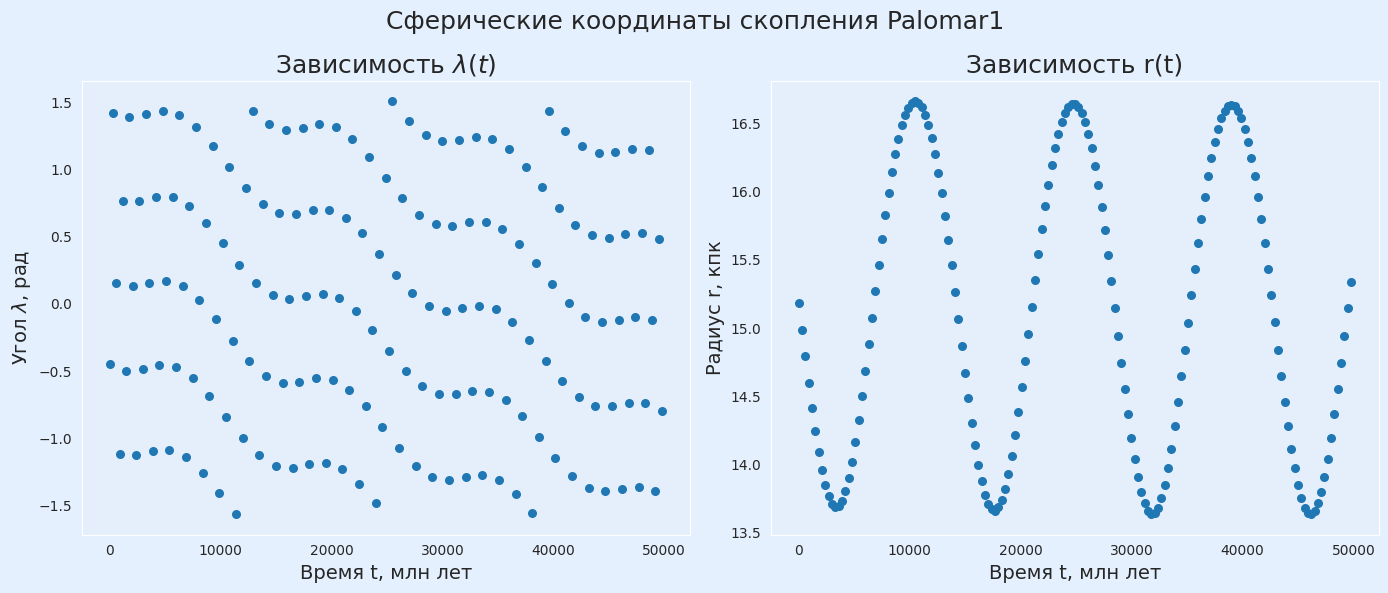

In [ ]:
group = 300
t = np.array(data['t'])[::group]
X = np.array(data["X"])[::group]
Y = np.array(data["Y"])[::group]
Z = np.array(data["Z"])[::group]

r = np.sqrt(X**2 + Y**2 + Z**2)
lambd = np.arctan(Y / X)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#519dfc')
fig.patch.set_alpha(0.15)

ax1.patch.set_alpha(0.15)
scatter1 = ax1.scatter(t, lambd, s=30)
ax1.set_xlabel('Время t, млн лет', fontsize=14)
ax1.set_ylabel('Угол $\\lambda$, рад', fontsize=14)
ax1.set_title('Зависимость $\\lambda(t)$', fontsize=18)
ax1.grid()

ax2.patch.set_alpha(0.15)
scatter2 = ax2.scatter(t, r, s=30)
ax2.set_xlabel('Время t, млн лет', fontsize=14)
ax2.set_ylabel('Радиус r, кпк', fontsize=14)
ax2.set_title('Зависимость r(t)', fontsize=18)
ax2.grid()

plt.suptitle('Сферические координаты скопления Palomar1', fontsize=18)

plt.tight_layout()
plt.show()

Какой вид имеют графики? Есть ли у них некий период? Какой функцией их можно было бы аппроксимировать? Какой период у графиков?

<font color='white'>Оба графика представляют собой периодические функции. Первый можно апроксимировать функцией -ax + sin(bx) а второй Qsin(wx). Период на втором графике - это период обращения скопления вокруг центра галактики, а на первом видно как период обращения вокруг центра (малые пики), так и период прецессии орбиты. Вообще из предыдущего трехмерного графика видно что скопление двигается по прецессирующему эллипсу, наклоненному относительно плоскости галактики, так что проекция его орбиты на эту плоскость почти круговая.</font>

# 4. О видах касатиков (2 балла)

Датасет ирисов использовался в статье Р.А. Фишера 1936 года «Использование множественных измерений в таксономических задачах», а в наши дни часто используется начинающими аналитиками данных.

В наборе данных включены три вида ирисов по 50 образцов каждый, а также некоторые свойства каждого цветка. Один вид цветка линейно отделим от двух других, но два других не отделимы линейно друг от друга.


Датасет можно получить при помощи:



```
from sklearn.datasets import load_iris
```



Столбцы в этом датасете:

Идентификатор (Id)

Длина чашелистика, см (SepalLengthCm)

Ширина чашелистика, см (SepalWidthCm)

Длина лепестка, см (PetalLengthCm)

Ширина лепестка, см (PetalWidthCm)

Вид (Species)

<font color='red'>ВНИМАНИЕ!</font> В данной части работы надо использовать **seaborn**.

In [ ]:
sns.set_style("darkgrid")

In [ ]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# Понятно, что колонка Id нам не очень нужна
# Поэтому давайте её удалим - HINT: используйте метод drop

# ее уже нет в iris по умолчанию :(
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Давайте проверим, сколько у нас разных видов ирисов в итоге - должно быть 3 по 50 штук каждый. Воспользуйтесь `value_counts` , чтобы посмотреть, какие есть возможные значения у колонки species.

In [ ]:
iris['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


## 4.1 Графики длины и ширины лепестка ириса (0.5 балла)

Давайте попробуем сравнить, связаны ли ширина и длина лепестков - воспользуйтесь `sns.scatterplot`, чтобы отобразить на оси OXY значения. Не забудьте подписать график и оси!

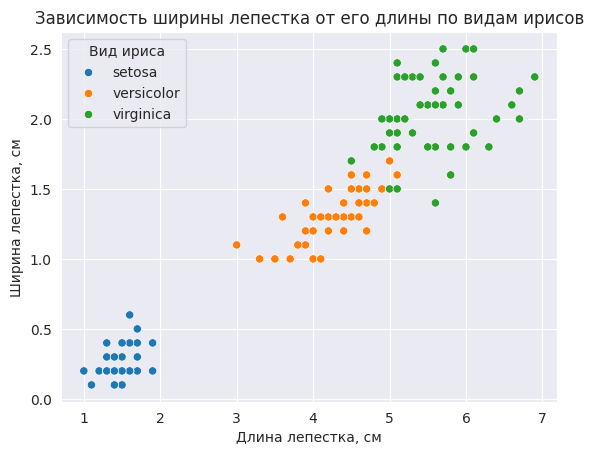

In [ ]:
scatter_plot = sns.scatterplot(
    data=iris,
    x='petal_length',
    y='petal_width',
    hue='species'
)
scatter_plot.set(
    xlabel='Длина лепестка, см',
    ylabel='Ширина лепестка, см',
    title='Зависимость ширины лепестка от его длины по видам ирисов'
)
scatter_plot.legend(title='Вид ириса')

Напишите, какие выводы можно сделать из графика. Чего графику не хватает, чтобы он был информативным?

<font color='white'>Из 3 групп явно выделяется setosa, её лепестки сильно меньше лепестков 2 других видов. Два других вида тоже в основной массе отличаются, но пограничные случаи уже очень похожи. Для установления связи между длиной и шириной на график стоит добавить апроксимацию, хотя уже заметна линейная зависисмость между длиной и шириной лепестков</font>

Давайте попробуем другие графики для тех же целей из библиотеки seaborn - `sns.jointplot`; кроме того, попробуйте выделить цветом точки на графике в зависимости от вида ириса - воспользуйтесь `sns.facetgrid`. В следующих ячейках выведите эти два графика и проанализируйте.

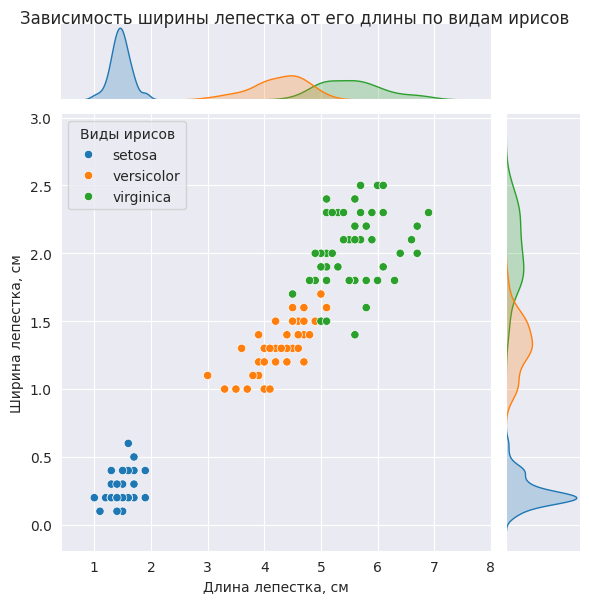

In [ ]:
joint_plot = sns.jointplot(
    data=iris,
    x='petal_length',
    y='petal_width',
    hue='species',
)
joint_plot.set_axis_labels('Длина лепестка, см', 'Ширина лепестка, см');
joint_plot.fig.suptitle('Зависимость ширины лепестка от его длины по видам ирисов', y = 1);
joint_plot.ax_joint.legend(title='Виды ирисов')

Text(0.5, 1, 'Длина и ширина лепестка по видам ирисов')

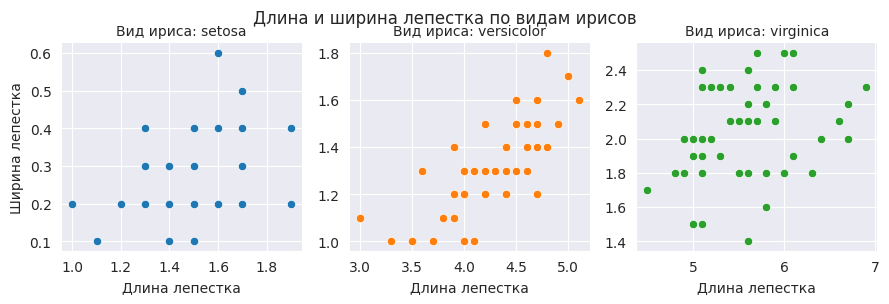

In [ ]:
g = sns.FacetGrid(iris, col='species', hue='species', sharex=False, sharey=False)
g.map(sns.scatterplot, 'petal_length', 'petal_width')
g.set_titles("Вид ириса: {col_name}")
g.set_axis_labels("Длина лепестка", "Ширина лепестка")
g.fig.suptitle('Длина и ширина лепестка по видам ирисов', y=1)

Какие выводы можно сделать из этих графиков? Какой из 3 методов - scatterplot, jointplot, facetgrid вам кажется лучше?

<font color='white'>Из jointplot благодаря диаграммам распределения длины и ширины лепестков можно сделать вывод что у вида setosa больширнство лепестков имеют одну и ту же длину и ширину, а у двух других видов наблюдается целый интервал подходящих значей, но есть и выраженные пики. Из facegrid можно сделать вывод о довольно выраженной линейной зависимости ширины и длины у вида versicolor, у вида virginica кажется есть 2 выделяющиеся подгруппы. Из 3 методов наверное лучший jointplot так как из него можно было получить все выводы написанные тут и в предыдущем пункте, так как он содержит диаграмму scatterplot. Но более наглядно посмотреть можно на каждый вид при помощи facegrid</font>

## 4.2 Графики распределений значений длины лепестка (0.75 балла)

Постройте график "ящика с усами" - `sns.boxplot` и его аналог - `sns.violinplot`. По оси Ox должны находиться возможные виды ирисов, по оси Oy.

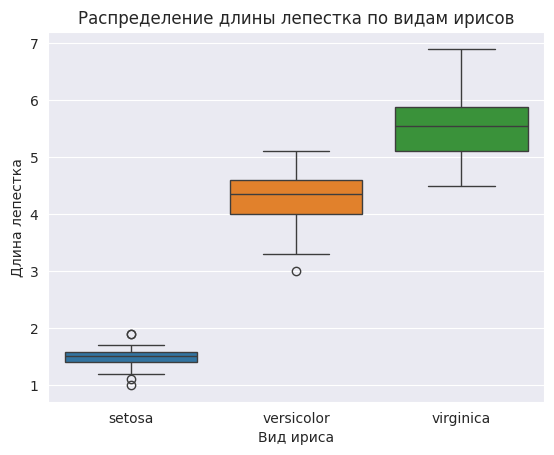

In [ ]:
boxplot = sns.boxplot(data=iris, x="species", y="petal_length", hue="species")
boxplot.set(xlabel = 'Вид ириса',
        ylabel = 'Длина лепестка',
        title = 'Распределение длины лепестка по видам ирисов');

[Text(0.5, 0, 'Вид ириса'),
 Text(0, 0.5, 'Длина лепестка'),
 Text(0.5, 1.0, 'Распределение длины лепестка по видам ирисов')]

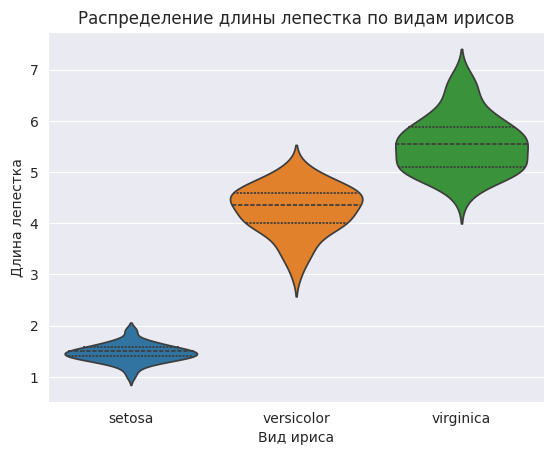

In [ ]:
violinplot = sns.violinplot(data=iris, x="species", y="petal_length", hue = "species",
               inner="quart") # inner="box"
violinplot.set(xlabel = 'Вид ириса',
               ylabel = 'Длина лепестка',
               title = 'Распределение длины лепестка по видам ирисов')

Сравните два вида графиков. Какой более информативный, а какой - более красивый визуально по вашему мнению? Какую информацию мы можем получить из этих графиков?

<font color='white'>Существенной разницы в информативности для данных графиков в этой задаче не наблюдается, разве что violinplot показывает распределение величины, но boxplot сразу показывает выбросы и автоматически выделяет полосу, которой принадлежит основная масса значений. Наверное поэтому я скажу что хоть и форма прикольнее у violinplot, но удобнее считать данные из boxplot и буду считать это основным критерием красивости. Violinplot был бы более информативен и нагляден, если бы мы сравнивали по одному признаку 2 группы как в семинарском примере с курящими и не курящими. Вообще изменив параметр inner с quart на box мы можем получить те же boxplot внутри violinplot, но читать по ним какую-либо информацию проблематично уже, поэтому остановимся на том что удобнее пользоваться boxplot, но если нужно взглянуть на распределение то можно нарисовать violinplot.</font>

## 4.3 Попарные графики взаимосвязи признаков (0.75 балла)


Давайте попробуем построить большую табличку из графиковв размера 4 на 4, где у нас находятся все возможные пары признаков (длина/ширина лепестка, длина/ширина чашелистика). Для этого воспользуйтесь `sns.pairplot` и не забудьте указать параметр `hue`.

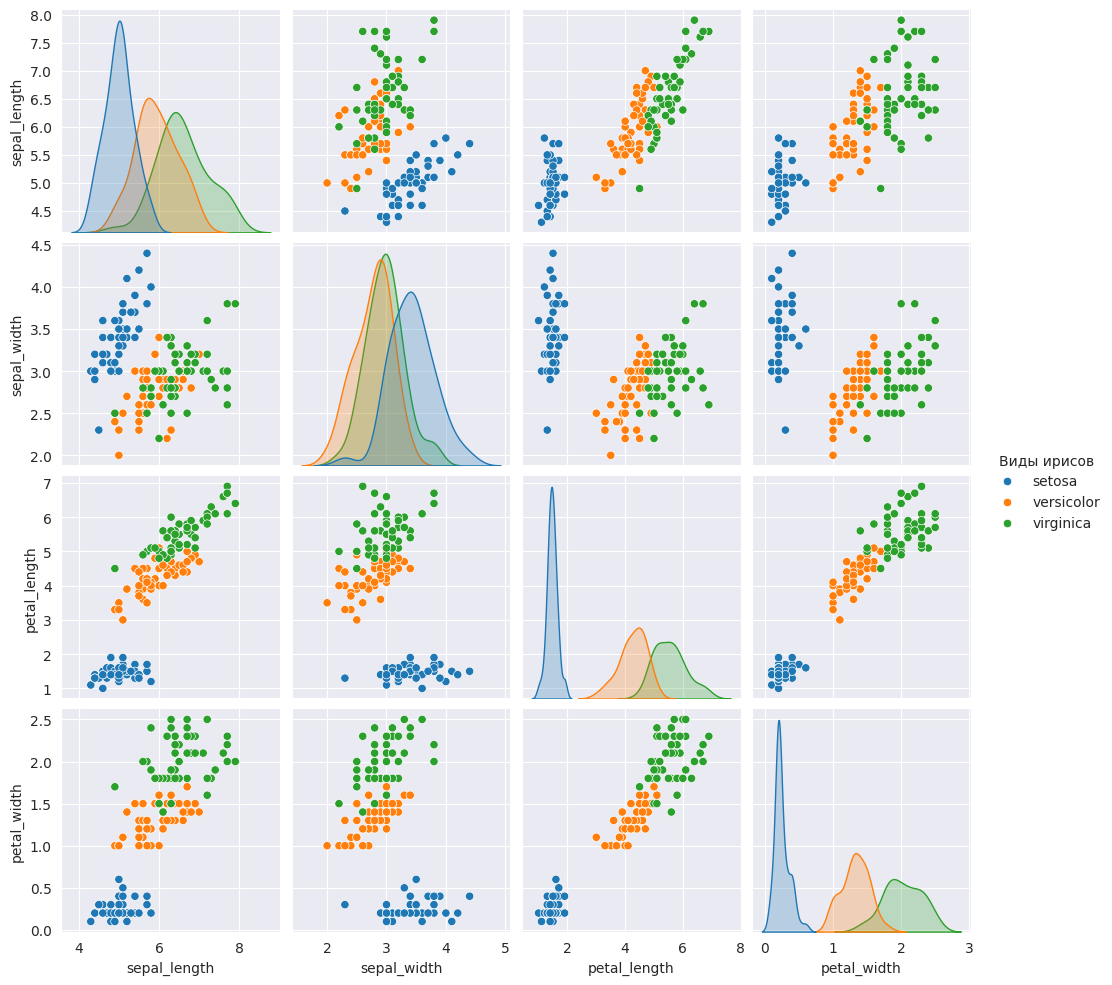

In [ ]:
pair_plot = sns.pairplot(data=iris, hue='species')
pair_plot.legend.set_title('Виды ирисов')

Какую информацию о взаимосвязи признаков вы можете почерпнуть из полученного графика?

<font color='white'>Можно сделать вывод о том что setosa легко визуально определяется как по параметрам лепестка, так и по параметрам чашелистика, однако благодаря распределениям на диагонали можно сделать вывод что лучше определять вид ириса по лепестку. Так же видно что почти невозможно отличить virginica от versicolor по параметрам чашелистика</font>

Какие графики находятся на диагонали этой таблицы?

<font color='white'> На диагонали находятся диаграммы распределения параметра ириса по видам.</font>

Попробуй заменить графики на диагонали таблицы на другие, возможно, более информативные (подсказка: в документации у `sns.pairplot` для этого есть специальный параметр). Выведи полученный график.

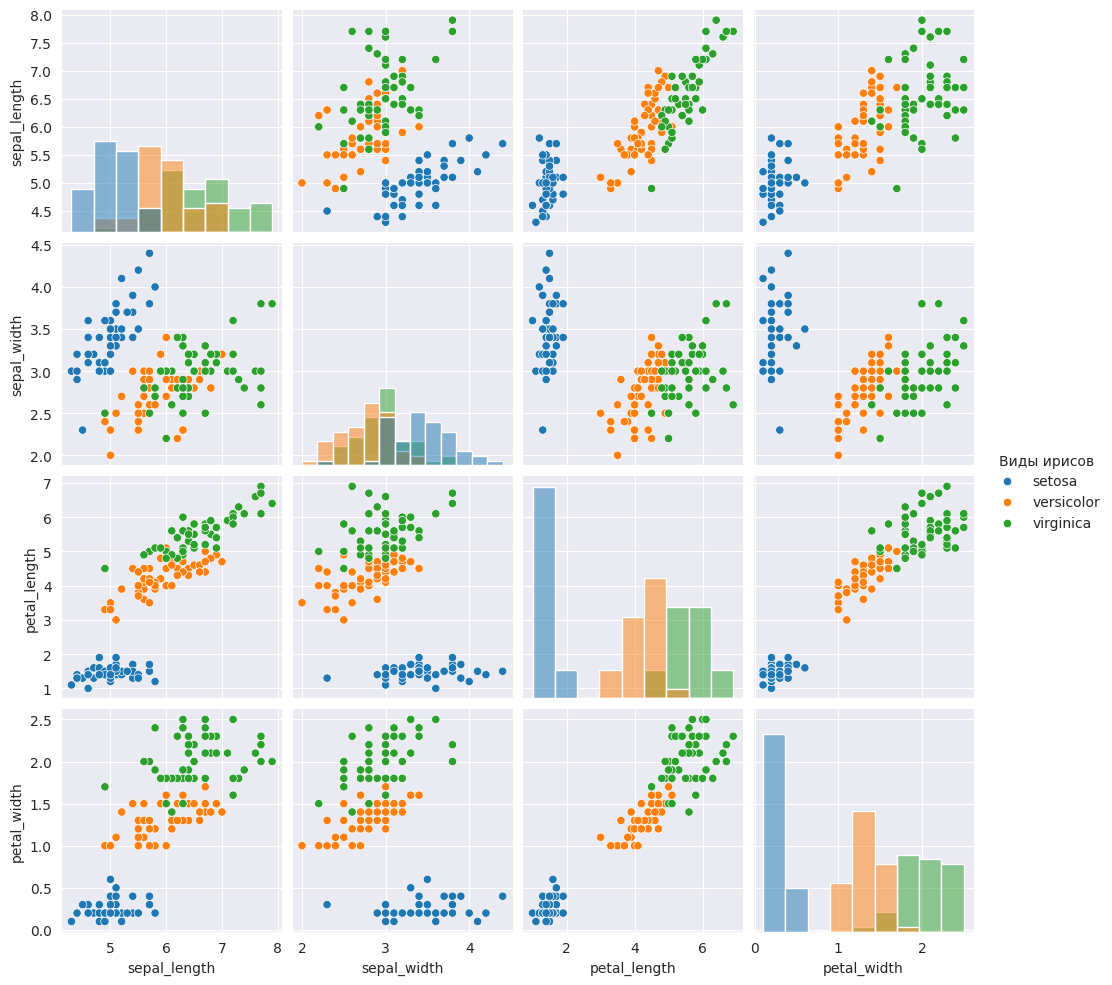

In [ ]:
pair_plot = sns.pairplot(data=iris, hue='species', diag_kind = 'hist')
pair_plot.legend.set_title('Виды ирисов')

Какие графики теперь находятся на диагонали таблицы? Получилось ли более информативно?

<font color='white'> Теперь на диагонали диаграммы. Проще считать количественные данные, на гистограммах связанные с параметрами чашелистика более явно видны пересечения. Однако информативности особо не прибавилось, так как первый вариант диаграммы это по сути те же гистограммы, просто сглаженные. Поэтому можно ничего не трогать первый вариант красивее)</font>